In [4]:
import pandas as pd


In [5]:
df = pd.read_csv('intl_nba.csv')
df

,Season (sort),Season,Player,Team,Age,Height,Weight,COLLEGE,COUNTRY,DRAFT YEAR,DRAFT ROUND,DRAFT NUMBER
0,2024,2024-25,Bruno Fernando,TOR,26,6-9,240.0,Maryland,Angola,2019,2,34
1,2023,2023-24,Bruno Fernando,ATL,25,6-9,240.0,Maryland,Angola,2019,2,34
2,2022,2022-23,Bruno Fernando,ATL,24,6-10,240.0,Maryland,Angola,2019,2,34
3,2021,2021-22,Bruno Fernando,HOU,23,6-9,240.0,Maryland,Angola,2019,2,34
4,2020,2020-21,Bruno Fernando,ATL,22,6-9,240.0,Maryland,Angola,2019,2,34
...,...,...,...,...,...,...,...,...,...,...,...,...
2624,2002,2002-03,Oscar Torres,GSW,26,NaN,NaN,NaN,Venezuela,Undrafted,Undrafted,Undrafted
2625,2001,2001-02,Oscar Torres,HOU,25,6-6,210.0,NaN,Venezuela,Undrafted,Undrafted,Undrafted
2626,1998,1998-99,Carl Herrera,DEN,32,6-9,225.0,Houston,Venezuela,1990,2,30
2627,1997,1997-98,Carl Herrera,SAS,31,6-9,225.0,Houston,Venezuela,1990,2,30


In [6]:
# This counts how many rows exist for each unique value in the 'Season' column
season_counts = df['Season'].value_counts().sort_index()

print(season_counts)

Season
1996-97     27
1997-98     26
1998-99     33
1999-00     35
2000-01     45
2001-02     51
2002-03     63
2003-04     65
2004-05     77
2005-06     80
2006-07     80
2007-08     77
2008-09     75
2009-10     78
2010-11     85
2011-12     84
2012-13     87
2013-14     93
2014-15    101
2015-16    102
2016-17    116
2017-18    115
2018-19    119
2019-20    126
2020-21    125
2021-22    133
2022-23    125
2023-24    132
2024-25    132
2025-26    142
Name: count, dtype: int64


In [7]:
# Create a new dataframe with only unique player names
unique_players = df.drop_duplicates(subset=['Player'])

# Check how many rows are in the new dataframe
print(len(unique_players))

540


In [8]:
# Reset the index so it goes from 0 to 539
unique_players = unique_players.reset_index(drop=True)

# Now look at it again
unique_players

,Season (sort),Season,Player,Team,Age,Height,Weight,COLLEGE,COUNTRY,DRAFT YEAR,DRAFT ROUND,DRAFT NUMBER
0,2024,2024-25,Bruno Fernando,TOR,26,6-9,240.0,Maryland,Angola,2019,2,34
1,2021,2021-22,Norvel Pelle,UTA,29,6-10,231.0,Iona,Antigua and Barbuda,Undrafted,Undrafted,Undrafted
2,2022,2022-23,Facundo Campazzo,DAL,32,5-10,195.0,NaN,Argentina,Undrafted,Undrafted,Undrafted
3,2022,2022-23,Leandro Bolmaro,UTA,22,6-6,200.0,NaN,Argentina,2020,1,23
4,2021,2021-22,Gabriel Deck,OKC,27,6-6,231.0,NaN,Argentina,Undrafted,Undrafted,Undrafted
...,...,...,...,...,...,...,...,...,...,...,...,...
535,2015,2015-16,Tim Duncan,SAS,40,6-11,250.0,Wake Forest,US Virgin Islands,1997,1,1
536,2011,2011-12,Raja Bell,UTA,35,6-5,210.0,Florida International,US Virgin Islands,Undrafted,Undrafted,Undrafted
537,2016,2016-17,Greivis Vasquez,BKN,30,6-6,217.0,Maryland,Venezuela,2010,1,28
538,2002,2002-03,Oscar Torres,GSW,26,NaN,NaN,NaN,Venezuela,Undrafted,Undrafted,Undrafted


In [9]:
# Create a ranked list of countries
country_counts = unique_players['COUNTRY'].value_counts().reset_index()

# Rename the columns so they look professional
country_counts.columns = ['COUNTRY', 'Player_Count']

# Show the top 10
country_counts.head(10)

,COUNTRY,Player_Count
0,France,56
1,Canada,53
2,Australia,34
3,Serbia,31
4,Croatia,20
5,Brazil,17
6,Germany,16
7,Spain,16
8,Argentina,15
9,Lithuania,15


In [10]:
# 1. Define the continent_map (The source data)
continent_map = {
    'Europe': ['France', 'Serbia', 'Croatia', 'Germany', 'Spain', 'Lithuania', 'Turkey', 'Greece', 'Russia', 'Slovenia', 'Ukraine', 'Italy', 'United Kingdom', 'Netherlands', 'Bosnia and Herzegovina', 'Georgia', 'Latvia', 'Montenegro', 'Czech Republic', 'Israel', 'Poland', 'Sweden', 'Switzerland', 'Belgium', 'Finland', 'Estonia', 'Austria', 'Bulgaria', 'Denmark', 'Ireland', 'Macedonia', 'Portugal', 'Romania', 'Scotland'],
    'North America': ['Canada', 'Dominican Republic', 'Puerto Rico', 'Jamaica', 'Mexico', 'Bahamas', 'Haiti', 'US Virgin Islands', 'Antigua and Barbuda', 'Belize', 'British Virgin Islands', 'Cuba', 'Nicaragua', 'Panama', 'Saint Lucia', 'St. Vincent & Grenadines', 'Trinidad and Tobago'],
    'Africa': ['Senegal', 'Nigeria', 'Cameroon', 'South Sudan', 'DRC', 'Mali', 'Congo', 'Gabon', 'Ghana', 'Guinea', 'Angola', 'Cabo Verde', 'Egypt', 'Sudan', 'Tanzania', 'Tunisia'],
    'South America': ['Brazil', 'Argentina', 'Venezuela', 'Colombia', 'Uruguay'],
    'Oceania': ['Australia', 'New Zealand'],
    'Asia': ['China', 'Japan', 'Iran', 'Lebanon', 'South Korea']
}

# 2. Create the empty dictionary to hold the results
country_to_continent = {}

# 3. The loop that creates your mapping
for continent, country_list in continent_map.items():
    for country_name in country_list:
        country_to_continent[country_name] = continent

# 4. Test it
print(f"Total countries mapped: {len(country_to_continent)}")

Total countries mapped: 79


In [11]:
country_to_continent

{'France': 'Europe',
 'Serbia': 'Europe',
 'Croatia': 'Europe',
 'Germany': 'Europe',
 'Spain': 'Europe',
 'Lithuania': 'Europe',
 'Turkey': 'Europe',
 'Greece': 'Europe',
 'Russia': 'Europe',
 'Slovenia': 'Europe',
 'Ukraine': 'Europe',
 'Italy': 'Europe',
 'United Kingdom': 'Europe',
 'Netherlands': 'Europe',
 'Bosnia and Herzegovina': 'Europe',
 'Georgia': 'Europe',
 'Latvia': 'Europe',
 'Montenegro': 'Europe',
 'Czech Republic': 'Europe',
 'Israel': 'Europe',
 'Poland': 'Europe',
 'Sweden': 'Europe',
 'Switzerland': 'Europe',
 'Belgium': 'Europe',
 'Finland': 'Europe',
 'Estonia': 'Europe',
 'Austria': 'Europe',
 'Bulgaria': 'Europe',
 'Denmark': 'Europe',
 'Ireland': 'Europe',
 'Macedonia': 'Europe',
 'Portugal': 'Europe',
 'Romania': 'Europe',
 'Scotland': 'Europe',
 'Canada': 'North America',
 'Dominican Republic': 'North America',
 'Puerto Rico': 'North America',
 'Jamaica': 'North America',
 'Mexico': 'North America',
 'Bahamas': 'North America',
 'Haiti': 'North America',
 'U

In [12]:
# Create the column 'Continent' by mapping the 'COUNTRY' column
df['Continent'] = df['COUNTRY'].map(country_to_continent)

# Check the first few rows to confirm it worked
print(df[['COUNTRY', 'Continent']].head(10))

               COUNTRY      Continent
0               Angola         Africa
1               Angola         Africa
2               Angola         Africa
3               Angola         Africa
4               Angola         Africa
5               Angola         Africa
6  Antigua and Barbuda  North America
7  Antigua and Barbuda  North America
8  Antigua and Barbuda  North America
9            Argentina  South America


In [13]:
df.head(30)

,Season (sort),Season,Player,Team,Age,Height,Weight,COLLEGE,COUNTRY,DRAFT YEAR,DRAFT ROUND,DRAFT NUMBER,Continent
0,2024,2024-25,Bruno Fernando,TOR,26,6-9,240.0,Maryland,Angola,2019,2,34,Africa
1,2023,2023-24,Bruno Fernando,ATL,25,6-9,240.0,Maryland,Angola,2019,2,34,Africa
2,2022,2022-23,Bruno Fernando,ATL,24,6-10,240.0,Maryland,Angola,2019,2,34,Africa
3,2021,2021-22,Bruno Fernando,HOU,23,6-9,240.0,Maryland,Angola,2019,2,34,Africa
4,2020,2020-21,Bruno Fernando,ATL,22,6-9,240.0,Maryland,Angola,2019,2,34,Africa
5,2019,2019-20,Bruno Fernando,ATL,21,6-9,240.0,Maryland,Angola,2019,2,34,Africa
6,2021,2021-22,Norvel Pelle,UTA,29,6-10,231.0,Iona,Antigua and Barbuda,Undrafted,Undrafted,Undrafted,North America
7,2020,2020-21,Norvel Pelle,NYK,28,6-10,231.0,Iona,Antigua and Barbuda,Undrafted,Undrafted,Undrafted,North America
8,2019,2019-20,Norvel Pelle,PHI,27,6-10,231.0,Iona,Antigua and Barbuda,Undrafted,Undrafted,Undrafted,North America
9,2022,2022-23,Facundo Campazzo,DAL,32,5-10,195.0,NaN,Argentina,Undrafted,Undrafted,Undrafted,South America


In [14]:
# Add the Continent column to your unique_players dataframe
unique_players['Continent'] = unique_players['COUNTRY'].map(country_to_continent)

# Verify it's there by looking at the first 5 rows
unique_players[['COUNTRY', 'Continent']].head()

,COUNTRY,Continent
0,Angola,Africa
1,Antigua and Barbuda,North America
2,Argentina,South America
3,Argentina,South America
4,Argentina,South America


In [15]:
# 1. Group and count
continent_summary = unique_players['Continent'].value_counts().reset_index()
continent_summary.columns = ['Continent', 'Count']

# 2. Calculate percentages
total_players = 540 # Your confirmed total
continent_summary['Share (%)'] = (continent_summary['Count'] / total_players * 100).round(2)

# 3. Final Output
print("NBA International Talent by Continent (Unique Players)")
print("-" * 50)
print(continent_summary)

NBA International Talent by Continent (Unique Players)
--------------------------------------------------
       Continent  Count  Share (%)
0         Europe    296      54.81
1  North America     95      17.59
2         Africa     62      11.48
3  South America     37       6.85
4        Oceania     36       6.67
5           Asia     14       2.59


In [16]:
# .groupby('Club') separates the data by team
# ['Player'].nunique() counts each player only once per team
team_summary = df.groupby('Team')['Player'].nunique().reset_index()

# Rename columns for your report
team_summary.columns = ['Team', 'Unique Players']

# Sort them from highest to lowest
team_summary = team_summary.sort_values(by='Unique Players', ascending=False).reset_index(drop=True)

# Display the result
print(team_summary)

   Team  Unique Players
0   TOR              60
1   DAL              50
2   BOS              47
3   PHX              46
4   UTA              45
5   SAS              45
6   ATL              45
7   CLE              43
8   NYK              43
9   MIL              43
10  HOU              43
11  GSW              42
12  CHI              42
13  SAC              41
14  PHI              41
15  POR              39
16  MIN              39
17  LAC              38
18  ORL              36
19  DET              36
20  DEN              35
21  LAL              35
22  WAS              34
23  CHA              33
24  MEM              33
25  OKC              32
26  IND              31
27  BKN              30
28  MIA              26
29  NOP              20
30  NJN              17
31  SEA              16
32  NOH              14
33  VAN               4
34  CHH               3
35  NOK               3


In [17]:
# 1. Group by Season and count unique countries
# Adjust 'Season' to 'SEASON' if your column names are all caps
season_expansion = df.groupby('Season')['COUNTRY'].nunique().reset_index()

# 2. Rename columns for your report
season_expansion.columns = ['Season', 'Unique Countries']

# 3. Sort by season to ensure the timeline is correct
season_expansion = season_expansion.sort_values('Season')

# 4. Display the results
print(season_expansion)

     Season  Unique Countries
0   1996-97                17
1   1997-98                20
2   1998-99                23
3   1999-00                25
4   2000-01                28
5   2001-02                30
6   2002-03                33
7   2003-04                31
8   2004-05                35
9   2005-06                39
10  2006-07                36
11  2007-08                34
12  2008-09                35
13  2009-10                37
14  2010-11                40
15  2011-12                40
16  2012-13                37
17  2013-14                38
18  2014-15                37
19  2015-16                37
20  2016-17                41
21  2017-18                43
22  2018-19                43
23  2019-20                41
24  2020-21                42
25  2021-22                46
26  2022-23                42
27  2023-24                45
28  2024-25                45
29  2025-26                47


In [18]:
# 1. Group the data and count players per team per season
# (Using 'Season' and 'CLUB'—adjust if your columns are capitalized differently)
season_club_counts = df.groupby(['Season', 'Team']).size().reset_index(name='Count')

# 2. Sort so that:
#    - Seasons are chronological (descending)
#    - Within each season, the team with the most players is at the top
season_club_counts = season_club_counts.sort_values(by=['Season', 'Count'], ascending=[False, False])

# 3. Print the report with totals
for season in season_club_counts['Season'].unique():
    print(f"\n{season}")
    print("-" * 15)
    
    # Get all teams for this specific season
    season_data = season_club_counts[season_club_counts['Season'] == season]
    
    for _, row in season_data.iterrows():
        print(f"{row['Team']}\t{row['Count']}")
    
    # Print the season total
    print(f"{season} Total: {season_data['Count'].sum()}")


2025-26
---------------
ATL	10
BOS	8
CHI	7
POR	7
GSW	6
LAC	6
MEM	6
MIA	6
CLE	5
IND	5
NYK	5
OKC	5
ORL	5
SAC	5
SAS	5
UTA	5
WAS	5
CHA	4
HOU	4
LAL	4
MIL	4
MIN	4
TOR	4
BKN	3
DAL	3
DEN	3
PHI	3
NOP	2
PHX	2
DET	1
2025-26 Total: 142

2024-25
---------------
POR	8
OKC	7
HOU	6
LAL	6
ORL	6
TOR	6
ATL	5
CHA	5
CHI	5
DAL	5
GSW	5
LAC	5
MIN	5
SAS	5
DEN	4
IND	4
MEM	4
NOP	4
NYK	4
PHI	4
SAC	4
WAS	4
BKN	3
BOS	3
DET	3
MIA	3
PHX	3
UTA	3
CLE	2
MIL	1
2024-25 Total: 132

2023-24
---------------
DAL	8
OKC	7
POR	7
BOS	6
CHA	6
GSW	6
NYK	6
ORL	6
SAS	6
ATL	5
DET	5
PHI	5
PHX	5
SAC	5
CHI	4
HOU	4
IND	4
LAC	4
MEM	4
MIL	4
TOR	4
WAS	4
MIN	3
UTA	3
BKN	2
DEN	2
LAL	2
MIA	2
NOP	2
CLE	1
2023-24 Total: 132

2022-23
---------------
DAL	9
TOR	8
OKC	7
IND	6
MIL	6
ORL	6
SAC	6
SAS	6
UTA	6
ATL	5
CHA	4
CLE	4
DEN	4
DET	4
MEM	4
NYK	4
PHX	4
BKN	3
HOU	3
LAC	3
LAL	3
NOP	3
WAS	3
BOS	2
CHI	2
GSW	2
MIA	2
MIN	2
PHI	2
POR	2
2022-23 Total: 125

2021-22
---------------
OKC	11
TOR	9
DAL	8
WAS	7
IND	6
MEM	6
UTA	6
ATL	5
DET	5
MIL	5
ORL	5
SAC	5
BOS	4

In [19]:
import pandas as pd

# 1. Create the full Pivot Table for all teams
# Using your confirmed columns: 'Season', 'Team', and 'Player'
full_matrix = df.pivot_table(index='Season', 
                             columns='Team', 
                             values='Player', 
                             aggfunc='count', 
                             fill_value=0, 
                             margins=True, 
                             margins_name='Grand Total')

# 2. Sort chronologically (Newest Season first) while keeping Grand Total at the bottom
seasons_only = full_matrix.drop('Grand Total')
grand_total_row = full_matrix.loc[['Grand Total']]
full_matrix_sorted = pd.concat([seasons_only.sort_index(ascending=False), grand_total_row])

# 3. Set display options so Jupyter doesn't "hide" the middle columns
pd.set_option('display.max_columns', None)

# 4. Display the full matrix
full_matrix_sorted

Team,ATL,BKN,BOS,CHA,CHH,CHI,CLE,DAL,DEN,DET,GSW,HOU,IND,LAC,LAL,MEM,MIA,MIL,MIN,NJN,NOH,NOK,NOP,NYK,OKC,ORL,PHI,PHX,POR,SAC,SAS,SEA,TOR,UTA,VAN,WAS,Grand Total
Season,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-26,10,3,8,4,0,7,5,3,3,1,6,4,5,6,4,6,6,4,4,0,0,0,2,5,5,5,3,2,7,5,5,0,4,5,0,5,142
2024-25,5,3,3,5,0,5,2,5,4,3,5,6,4,5,6,4,3,1,5,0,0,0,4,4,7,6,4,3,8,4,5,0,6,3,0,4,132
2023-24,5,2,6,6,0,4,1,8,2,5,6,4,4,4,2,4,2,4,3,0,0,0,2,6,7,6,5,5,7,5,6,0,4,3,0,4,132
2022-23,5,3,2,4,0,2,4,9,4,4,2,3,6,3,3,4,2,6,2,0,0,0,3,4,7,6,2,4,2,6,6,0,8,6,0,3,125
2021-22,5,3,4,3,0,3,4,8,4,5,3,4,6,3,2,6,3,5,2,0,0,0,2,2,11,5,3,4,3,5,3,0,9,6,0,7,133
2020-21,4,2,4,3,0,6,6,7,5,4,4,3,3,3,3,4,3,5,3,0,0,0,6,3,7,3,4,3,2,2,5,0,6,5,0,7,125
2019-20,3,4,4,3,0,4,5,6,4,3,4,5,3,2,1,6,4,3,2,0,0,0,2,3,6,3,8,7,4,5,5,0,6,4,0,7,126
2018-19,2,2,5,4,0,3,6,8,5,4,2,4,3,7,2,5,2,4,6,0,0,0,2,3,4,3,5,3,3,3,5,0,5,7,0,2,119
2017-18,2,2,6,3,0,4,4,6,4,1,3,4,3,3,4,4,2,5,3,0,0,0,2,5,2,5,7,2,2,4,6,0,6,8,0,3,115


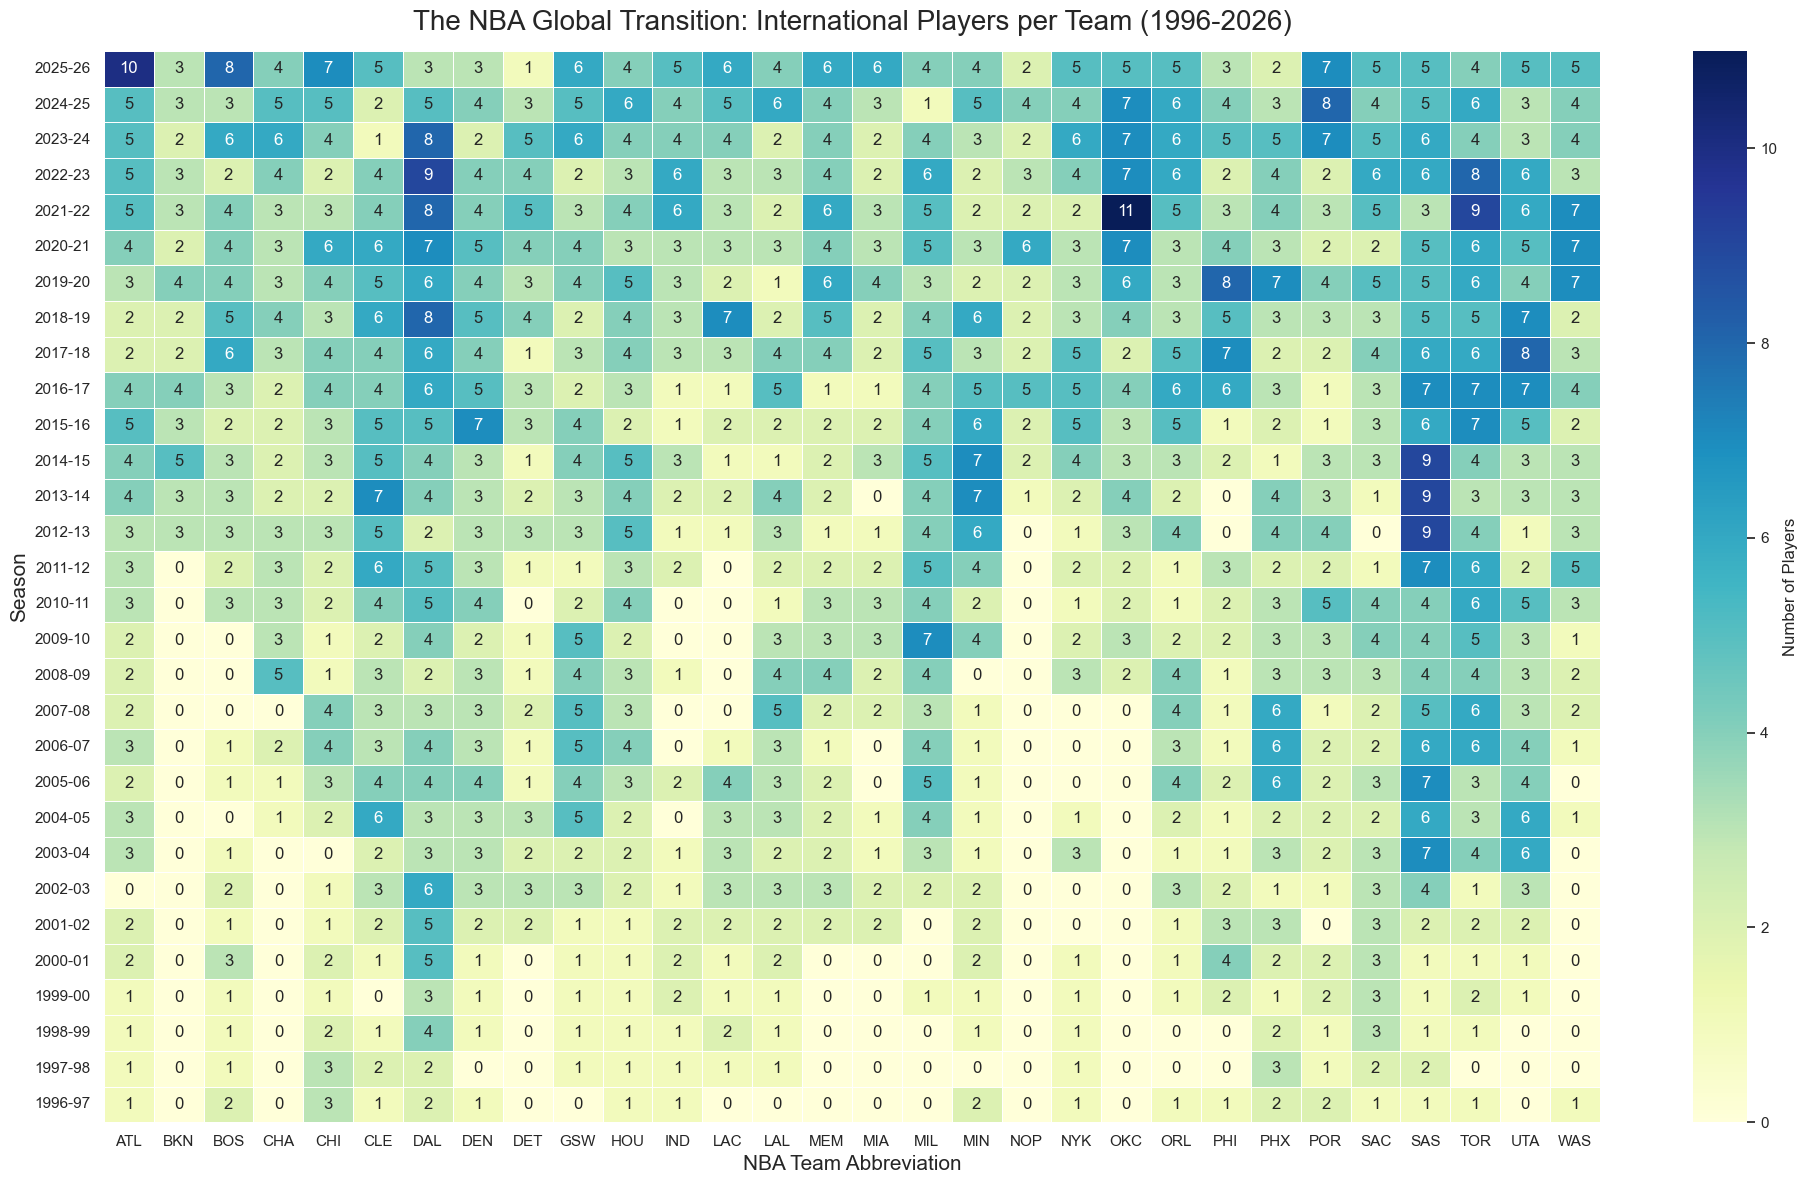

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data
# We remove 'Grand Total' and the 6 specified teams along the columns (axis=1)
# errors='ignore' ensures it won't crash if a team abbreviation isn't present
teams_to_exclude = ['CHH', 'NJN', 'NOH', 'NOK', 'SEA', 'VAN', 'Grand Total']

data_for_heatmap = full_matrix_sorted.drop('Grand Total', axis=0).drop(columns=teams_to_exclude, errors='ignore')

# 2. Set the style and size
plt.figure(figsize=(20, 12)) # Large size to fit all teams
sns.set_theme(style="white")

# 3. Create the Heatmap
heatmap = sns.heatmap(data_for_heatmap, 
                      annot=True, 
                      fmt="d", 
                      cmap="YlGnBu", 
                      linewidths=.5,
                      cbar_kws={'label': 'Number of Players'})

# 4. Labeling
plt.title('The NBA Global Transition: International Players per Team (1996-2026)', fontsize=20, pad=15)
plt.xlabel('NBA Team Abbreviation', fontsize=15)
plt.ylabel('Season', fontsize=15)

# 6. Save and Show
plt.tight_layout()

# Save the heatmap cleanly as a file before rendering
plt.savefig('nba_global_transition_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

In [21]:
import pandas as pd

# 1. Create the Count Matrix
count_matrix = df.pivot_table(index='Season', 
                             columns='COUNTRY', 
                             values='Player', 
                             aggfunc='count', 
                             fill_value=0)

# 2. Create the Share Matrix (Percentage of that season's total)
# We divide each row by the sum of that row
share_matrix = count_matrix.div(count_matrix.sum(axis=1), axis=0) * 100

# 3. Combine them into a "Display Matrix" of strings
# This creates a table of text formatted as "Count (Percentage%)"
display_matrix = count_matrix.astype(str) + " (" + share_matrix.round(1).astype(str) + "%)"

# 4. Clean up: Replace "0 (0.0%)" with a dash or empty string to make it readable
display_matrix = display_matrix.replace("0 (0.0%)", "—")

# 5. Sort newest season to top and show a few countries as a test
# (You can remove the column filter to see all 47+ countries)
display_matrix = display_matrix.sort_index(ascending=False)
display_matrix.head(30)

COUNTRY,Angola,Antigua and Barbuda,Argentina,Australia,Austria,Bahamas,Belgium,Belize,Bosnia and Herzegovina,Brazil,British Virgin Islands,Bulgaria,Cabo Verde,Cameroon,Canada,China,Colombia,Congo,Croatia,Cuba,Czech Republic,DRC,Denmark,Dominican Republic,Egypt,Estonia,Finland,France,Gabon,Georgia,Germany,Ghana,Greece,Guinea,Haiti,Iran,Ireland,Israel,Italy,Jamaica,Japan,Latvia,Lebanon,Lithuania,Macedonia,Mali,Mexico,Montenegro,Netherlands,New Zealand,Nicaragua,Nigeria,Panama,Poland,Portugal,Puerto Rico,Romania,Russia,Saint Lucia,Scotland,Senegal,Serbia,Slovenia,South Korea,South Sudan,Spain,St. Vincent & Grenadines,Sudan,Sweden,Switzerland,Tanzania,Trinidad and Tobago,Tunisia,Turkey,US Virgin Islands,Ukraine,United Kingdom,Uruguay,Venezuela
Season,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-26,—,—,—,10 (7.0%),1 (0.7%),3 (2.1%),2 (1.4%),—,2 (1.4%),1 (0.7%),—,—,—,4 (2.8%),22 (15.5%),1 (0.7%),—,—,2 (1.4%),—,1 (0.7%),3 (2.1%),—,3 (2.1%),—,—,1 (0.7%),22 (15.5%),—,2 (1.4%),7 (4.9%),—,3 (2.1%),1 (0.7%),1 (0.7%),—,—,2 (1.4%),2 (1.4%),1 (0.7%),2 (1.4%),1 (0.7%),—,3 (2.1%),—,1 (0.7%),—,1 (0.7%),3 (2.1%),1 (0.7%),1 (0.7%),4 (2.8%),—,1 (0.7%),1 (0.7%),1 (0.7%),—,2 (1.4%),1 (0.7%),—,1 (0.7%),4 (2.8%),1 (0.7%),—,2 (1.4%),2 (1.4%),—,—,2 (1.4%),3 (2.1%),—,—,—,2 (1.4%),—,2 (1.4%),3 (2.1%),—,—
2024-25,1 (0.8%),—,—,13 (9.8%),1 (0.8%),3 (2.3%),2 (1.5%),—,2 (1.5%),1 (0.8%),—,—,—,5 (3.8%),25 (18.9%),1 (0.8%),—,—,2 (1.5%),—,1 (0.8%),3 (2.3%),—,2 (1.5%),—,—,1 (0.8%),15 (11.4%),—,2 (1.5%),8 (6.1%),—,1 (0.8%),—,1 (0.8%),—,—,1 (0.8%),2 (1.5%),1 (0.8%),2 (1.5%),1 (0.8%),—,2 (1.5%),—,2 (1.5%),—,1 (0.8%),3 (2.3%),1 (0.8%),—,4 (3.0%),—,1 (0.8%),1 (0.8%),—,—,—,1 (0.8%),—,1 (0.8%),4 (3.0%),2 (1.5%),—,1 (0.8%),1 (0.8%),—,1 (0.8%),2 (1.5%),2 (1.5%),—,—,—,1 (0.8%),—,2 (1.5%),2 (1.5%),—,—
2023-24,1 (0.8%),—,—,10 (7.6%),1 (0.8%),2 (1.5%),1 (0.8%),—,1 (0.8%),2 (1.5%),1 (0.8%),1 (0.8%),—,2 (1.5%),24 (18.2%),—,—,—,4 (3.0%),—,1 (0.8%),3 (2.3%),—,2 (1.5%),—,1 (0.8%),1 (0.8%),14 (10.6%),—,2 (1.5%),6 (4.5%),1 (0.8%),2 (1.5%),1 (0.8%),—,—,—,1 (0.8%),3 (2.3%),1 (0.8%),2 (1.5%),2 (1.5%),—,2 (1.5%),—,1 (0.8%),—,1 (0.8%),—,—,—,5 (3.8%),—,1 (0.8%),1 (0.8%),—,—,—,1 (0.8%),—,2 (1.5%),7 (5.3%),1 (0.8%),—,2 (1.5%),2 (1.5%),—,1 (0.8%),—,1 (0.8%),—,—,—,5 (3.8%),—,3 (2.3%),3 (2.3%),—,—
2022-23,1 (0.8%),—,2 (1.6%),11 (8.8%),1 (0.8%),3 (2.4%),—,—,1 (0.8%),1 (0.8%),—,—,—,3 (2.4%),23 (18.4%),—,—,—,4 (3.2%),—,1 (0.8%),3 (2.4%),—,2 (1.6%),—,—,1 (0.8%),9 (7.2%),1 (0.8%),2 (1.6%),7 (5.6%),—,2 (1.6%),1 (0.8%),—,—,—,1 (0.8%),1 (0.8%),1 (0.8%),2 (1.6%),2 (1.6%),—,2 (1.6%),—,—,—,2 (1.6%),—,1 (0.8%),—,6 (4.8%),—,1 (0.8%),1 (0.8%),—,—,—,1 (0.8%),—,1 (0.8%),5 (4.0%),3 (2.4%),—,1 (0.8%),5 (4.0%),—,1 (0.8%),—,1 (0.8%),—,—,—,4 (3.2%),—,2 (1.6%),2 (1.6%),—,—
2021-22,1 (0.8%),1 (0.8%),3 (2.3%),6 (4.5%),1 (0.8%),3 (2.3%),—,—,1 (0.8%),2 (1.5%),—,—,—,2 (1.5%),21 (15.8%),—,1 (0.8%),—,2 (1.5%),—,2 (1.5%),4 (3.0%),1 (0.8%),2 (1.5%),1 (0.8%),—,1 (0.8%),14 (10.5%),1 (0.8%),2 (1.5%),8 (6.0%),—,3 (2.3%),1 (0.8%),—,—,—,1 (0.8%),1 (0.8%),1 (0.8%),2 (1.5%),2 (1.5%),—,4 (3.0%),—,1 (0.8%),—,2 (1.5%),—,1 (0.8%),—,5 (3.8%),—,—,1 (0.8%),—,—,—,1 (0.8%),—,2 (1.5%),5 (3.8%),3 (2.3%),—,1 (0.8%),5 (3.8%),—,1 (0.8%),—,1 (0.8%),—,—,—,5 (3.8%),—,2 (1.5%),2 (1.5%),—,—
2020-21,1 (0.8%),1 (0.8%),2 (1.6%),9 (7.2%),1 (0.8%),2 (1.6%),—,—,1 (0.8%),5 (4.0%),—,—,—,2 (1.6%),19 (15.2%),—,—,—,4 (3.2%),—,1 (0.8%),2 (1.6%),—,1 (0.8%),1 (0.8%),—,1 (0.8%),13 (10.4%),1 (0.8%),1 (0.8%),6 (4.8%),—,3 (2.4%),1 (0.8%),—,—,—,1 (0.8%),3 (2.4%),1 (0.8%),2 (1.6%),4 (3.2%),—,3 (2.4%),—,—,—,1 (0.8%),—,1 (0.8%),—,3 (2.4%),—,—,—,—,—,—,1 (0.8%),—,3 (2.4%),6 (4.8%),3 (2.4%),—,2 (1.6%),4 (3.2%),—,1 (0.8%),—,1 (0.8%),—,—,—,4 (3.2%),—,2 (1.6%),1 (0.8%),—,—
2019-20,1 (0.8%),1 (0.8%),—,9 (7.1%),1 (0.8%),2 (1.6%),—,—,2 (1.6%),3 (2.4%),—,—,—,3 (2.4%),21 (16.7%),—,—,—,7 (5.6%),—,1 (0.8%),3 (2.4%),—,1 (0.8%),1 (0.8%),—,1 (0.8%),12 (9.5%),1 (0.8%),1 (0.8%),6 (4.8%),—,3 (2.4%),—,1 (0.8%),—,—,—,3 (2.4%),—,2 (1.6%),4 (3.2%),—,2 (1.6%)

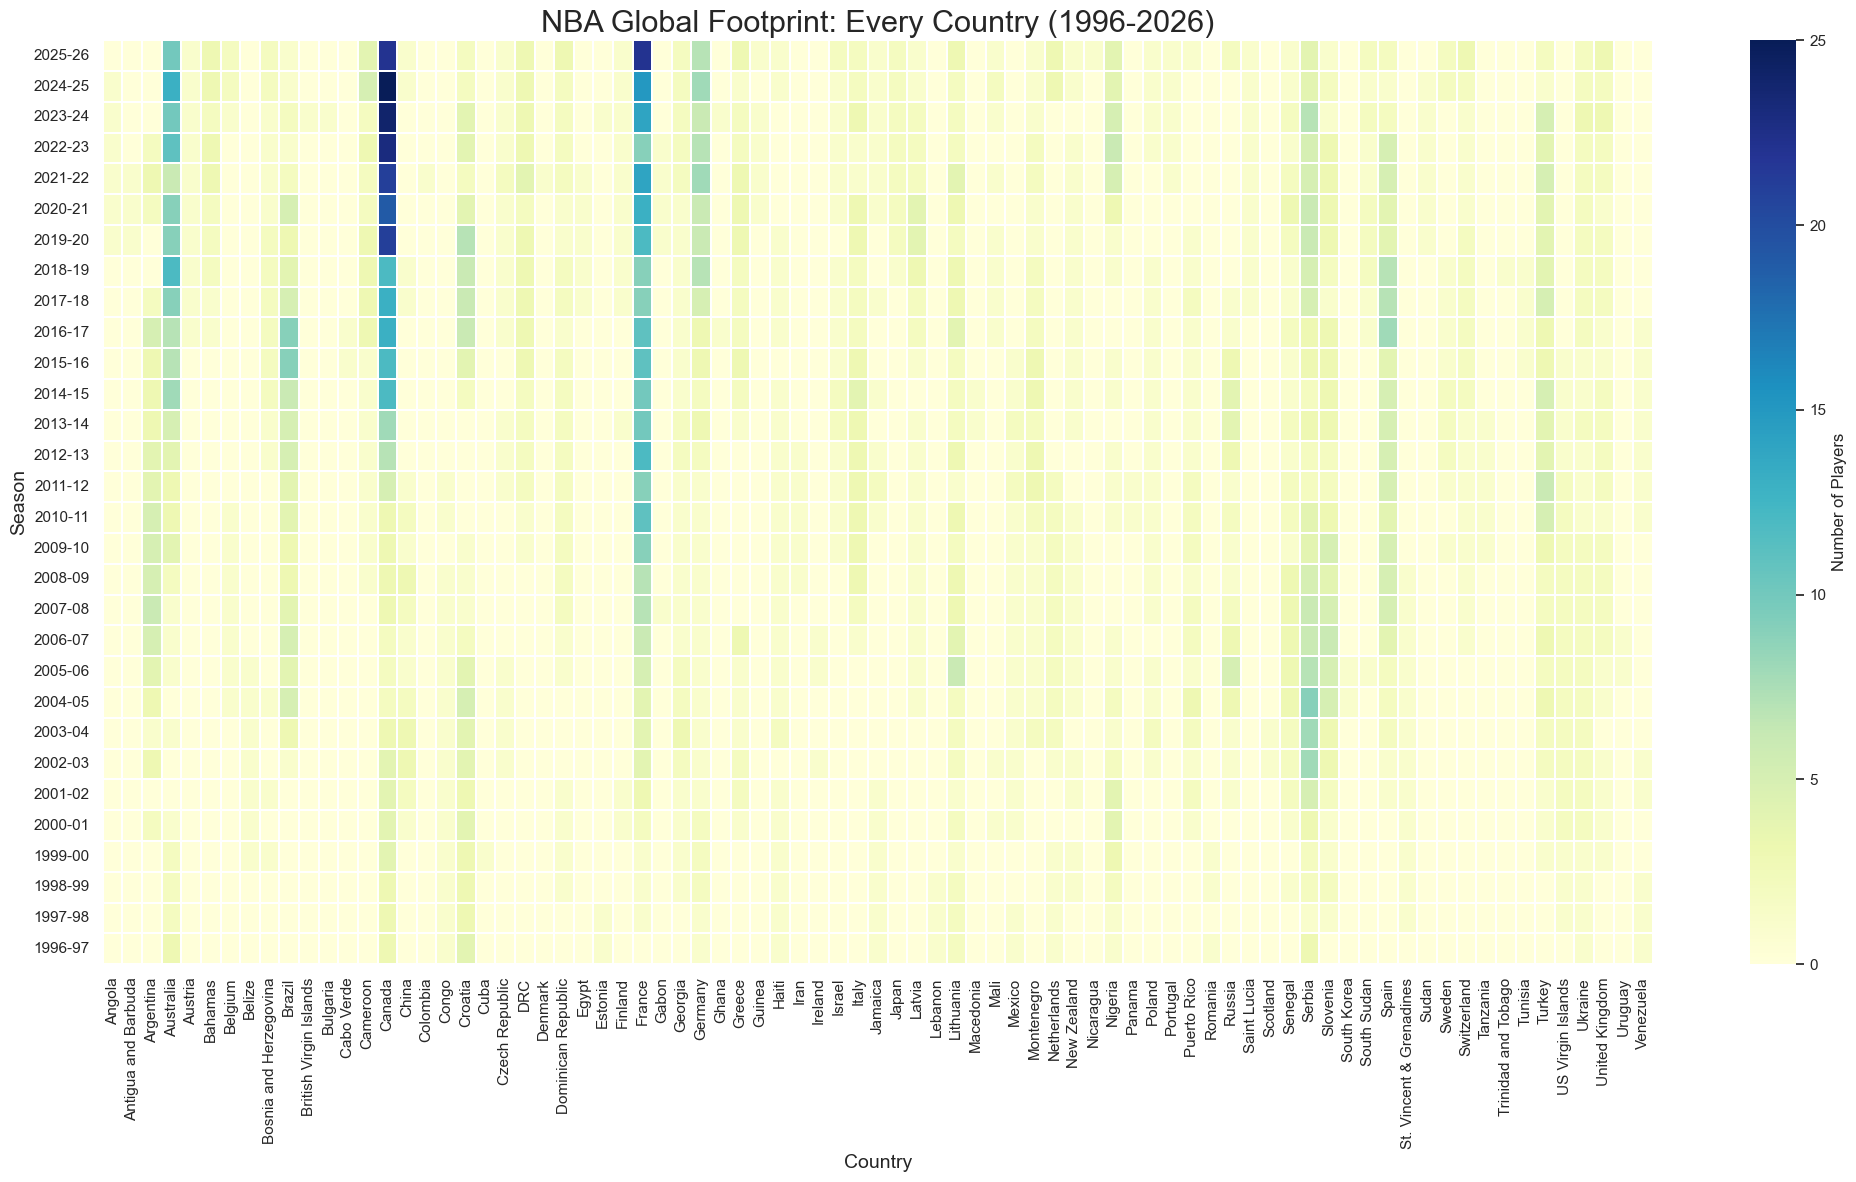

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup the data (using the count_matrix from our previous step)
# We sort seasons so the newest is at the top
all_countries_plot = count_matrix.sort_index(ascending=False)

# 2. Plotting
plt.figure(figsize=(25, 12)) # Extra wide to fit 47+ columns

# We set annot=False because text for 47 columns won't fit
sns.heatmap(all_countries_plot, 
            annot=False, 
            cmap="YlGnBu", 
            linewidths=.1, 
            cbar_kws={'label': 'Number of Players'})

plt.title('NBA Global Footprint: Every Country (1996-2026)', fontsize=22)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Season', fontsize=14)
plt.xticks(rotation=90) # Flip country names vertically so they don't overlap

plt.show()

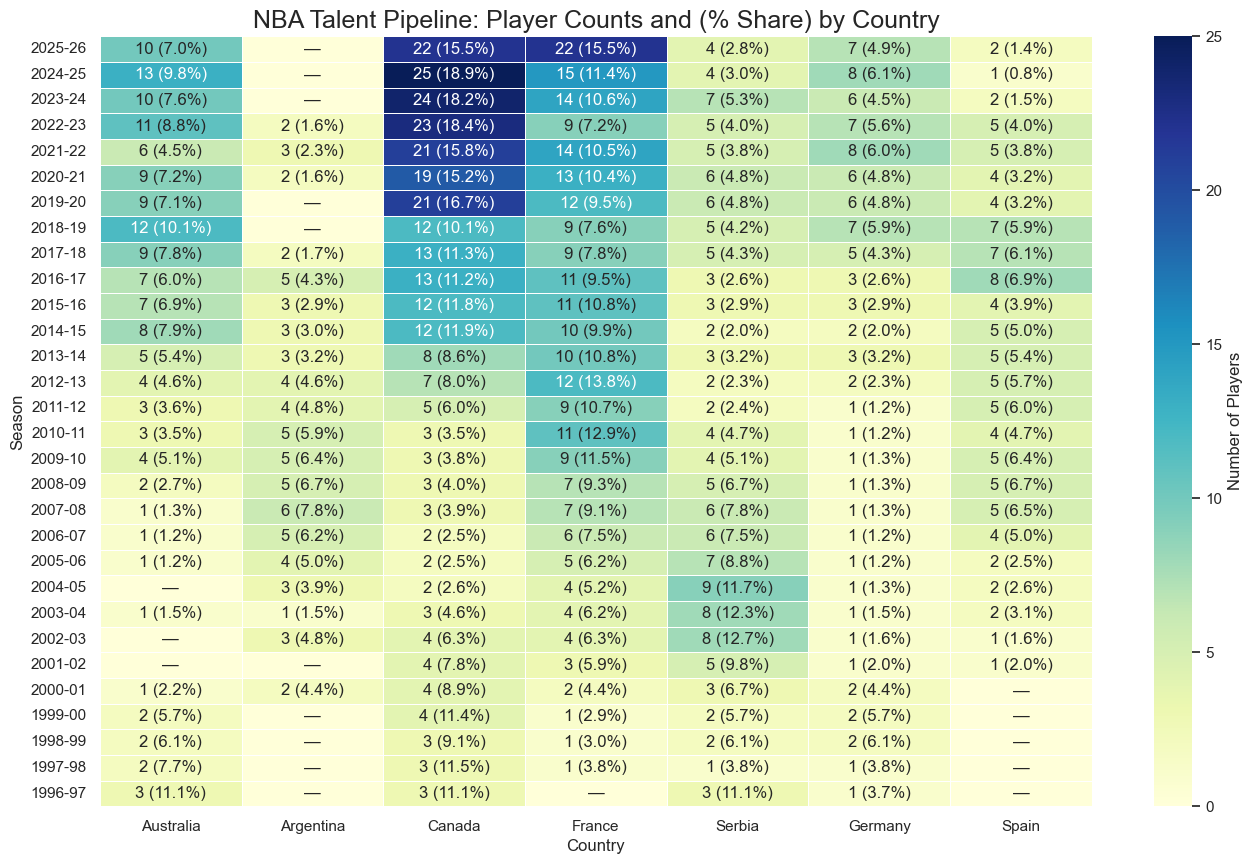

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data (assuming display_matrix and count_matrix exist from previous step)
# Drop the "Grand Total" row/col if you added them, as they skew the heatmap colors
plot_counts = count_matrix.sort_index(ascending=False)
plot_labels = display_matrix.sort_index(ascending=False)

# 2. Select a subset of countries to make it readable (or use all)
# Example: top_countries = ['Australia', 'Argentina', 'Canada', 'France', 'Serbia']
# To see ALL countries, just use: countries_to_plot = plot_counts.columns
countries_to_plot = ['Australia', 'Argentina', 'Canada', 'France', 'Serbia', 'Germany', 'Spain']

# 3. Create the plot
plt.figure(figsize=(16, 10))

# The magic trick: 'data' is for the colors, 'annot' is for the custom text labels
sns.heatmap(plot_counts[countries_to_plot], 
            annot=plot_labels[countries_to_plot], 
            fmt="",  # This must be empty when using custom string labels
            cmap="YlGnBu", 
            linewidths=.5,
            cbar_kws={'label': 'Number of Players'})

plt.title('NBA Talent Pipeline: Player Counts and (% Share) by Country', fontsize=18)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Season', fontsize=12)

plt.show()

In [24]:
import pandas as pd

# 1. Create the Count Matrix (Transposed: Countries as rows, Seasons as columns)
# index='COUNTRY' puts countries on the left
# columns='Season' puts years across the top
country_pivot = df.pivot_table(index='COUNTRY', 
                               columns='Season', 
                               values='Player', 
                               aggfunc='count', 
                               fill_value=0)

# 2. Sort seasons newest to oldest (left to right)
country_pivot = country_pivot.sort_index(axis=1, ascending=False)

# 3. Calculate the Share % per Season
# We divide by the sum of each COLUMN (axis=0) to see the share of that year
share_pivot = (country_pivot / country_pivot.sum(axis=0)) * 100

# 4. Merge into the "Count (Share%)" format
display_transposed = country_pivot.astype(str) + " (" + share_pivot.round(1).astype(str) + "%)"

# 5. Clean up zeros for better scannability
display_transposed = display_transposed.replace("0 (0.0%)", "—")

display_transposed

Season,2025-26,2024-25,2023-24,2022-23,2021-22,2020-21,2019-20,2018-19,2017-18,2016-17,2015-16,2014-15,2013-14,2012-13,2011-12,2010-11,2009-10,2008-09,2007-08,2006-07,2005-06,2004-05,2003-04,2002-03,2001-02,2000-01,1999-00,1998-99,1997-98,1996-97
COUNTRY,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Angola,—,1 (0.8%),1 (0.8%),1 (0.8%),1 (0.8%),1 (0.8%),1 (0.8%),—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
Antigua and Barbuda,—,—,—,—,1 (0.8%),1 (0.8%),1 (0.8%),—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
Argentina,—,—,—,2 (1.6%),3 (2.3%),2 (1.6%),—,—,2 (1.7%),5 (4.3%),3 (2.9%),3 (3.0%),3 (3.2%),4 (4.6%),4 (4.8%),5 (5.9%),5 (6.4%),5 (6.7%),6 (7.8%),5 (6.2%),4 (5.0%),3 (3.9%),1 (1.5%),3 (4.8%),—,2 (4.4%),—,—,—,—
Australia,10 (7.0%),13 (9.8%),10 (7.6%),11 (8.8%),6 (4.5%),9 (7.2%),9 (7.1%),12 (10.1%),9 (7.8%),7 (6.0%),7 (6.9%),8 (7.9%),5 (5.4%),4 (4.6%),3 (3.6%),3 (3.5%),4 (5.1%),2 (2.7%),1 (1.3%),1 (1.2%),1 (1.2%),—,1 (1.5%),—,—,1 (2.2%),2 (5.7%),2 (6.1%),2 (7.7%),3 (11.1%)
Austria,1 (0.7%),1 (0.8%),1 (0.8%),1 (0.8%),1 (0.8%),1 (0.8%),1 (0.8%),1 (0.8%),1 (0.9%),1 (0.9%),—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—,—
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
US Virgin Islands,—,—,—,—,—,—,—,—,—,—,1 (1.0%),1 (1.0%),1 (1.1%),1 (1.1%),2 (2.4%),2 (2.4%),2 (2.6%),2 (2.7%),2 (2.6%),2 (2.5%),2 (2.5%),2 (2.6%),2 (3.1%),2 (3.2%),2 (3.9%),2 (4.4%),1 (2.9%),1 (3.0%),1 (3.8%),—
Ukraine,2 (1.4%),2 (1.5%),3 (2.3%),2 (1.6%),2 (1.5%),2 (1.6%),2 (1.6%),2 (1.7%),2 (1.7%),2 (1.7%),1 (1.0%),1 (1.0%),2 (2.2%),1 (1.1%),1 (1.2%),1 (1.2%),2 (2.6%),2 (2.7%),2 (2.6%),2 (2.5%),2 (2.5%),2 (2.6%),2 (3.1%),2 (3.2%),2 (3.9%),2 (4.4%),1 (2.9%),1 (3.0%),1 (3.8%),1 (3.7%)
United Kingdom,3 (2.1%),2 (1.5%),3 (2.3%),2 (1.6%),2 (1.5%),1 (0.8%),2 (1.6%),2 (1.7%),2 (1.7%),1 (0.9%),1 (1.0%),2 (2.0%),2 (2.2%),2 (2.3%),2 (2.4%),1 (1.2%),2 (2.6%),2 (2.7%),2 (2.6%),2 (2.5%),1 (1.2%),1 (1.3%),—,1 (1.6%),1 (2.0%),1 (2.2%),1 (2.9%),—,—,—


In [25]:
# 1. Group by Season and Country, then count
country_counts = df.groupby(['Season', 'COUNTRY'])['Player'].count()

# 2. Sort within each season (Most players at the top)
# level=0 is Season, level=1 is Country
country_counts_sorted = country_counts.groupby(level=0, group_keys=False).nlargest(len(df))

# 3. Add the Season Total (just like your "1996-97 Total" line)
season_totals = df.groupby('Season')['Player'].count()

# 4. Display the results for the first few seasons
for season in sorted(df['Season'].unique(), reverse=True):
    print(f"--- {season} ---")
    print(country_counts_sorted[season])
    print(f"{season} Total: {season_totals[season]}\n")

--- 2025-26 ---
COUNTRY
Canada                    22
France                    22
Australia                 10
Germany                    7
Cameroon                   4
Nigeria                    4
Serbia                     4
Bahamas                    3
DRC                        3
Dominican Republic         3
Greece                     3
Lithuania                  3
Netherlands                3
Switzerland                3
United Kingdom             3
Belgium                    2
Bosnia and Herzegovina     2
Croatia                    2
Georgia                    2
Israel                     2
Italy                      2
Japan                      2
Russia                     2
South Sudan                2
Spain                      2
Sweden                     2
Turkey                     2
Ukraine                    2
Austria                    1
Brazil                     1
China                      1
Czech Republic             1
Finland                    1
Guinea             

In [26]:
import pandas as pd

# 1. Create the Pivot Table
# index='Season' (Rows), columns='Continent' (Columns)
continent_matrix = df.pivot_table(index='Season', 
                                  columns='Continent', 
                                  values='Player', 
                                  aggfunc='count', 
                                  fill_value=0, 
                                  margins=True, 
                                  margins_name='Grand Total')

# 2. Sort newest season to top
seasons_only = continent_matrix.drop('Grand Total')
grand_total_row = continent_matrix.loc[['Grand Total']]
continent_matrix_sorted = pd.concat([seasons_only.sort_index(ascending=False), grand_total_row])

# 3. Display
continent_matrix_sorted

Continent,Africa,Asia,Europe,North America,Oceania,South America,Grand Total
Season,,,,,,,
2025-26,16,3,78,33,11,1,142
2024-25,18,3,63,33,14,1,132
2023-24,19,2,68,31,10,2,132
2022-23,18,2,60,30,12,3,125
2021-22,20,2,69,29,7,6,133
2020-21,17,2,64,25,10,7,125
2019-20,16,2,67,28,10,3,126
2018-19,13,2,67,20,13,4,119
2017-18,11,1,65,21,10,7,115


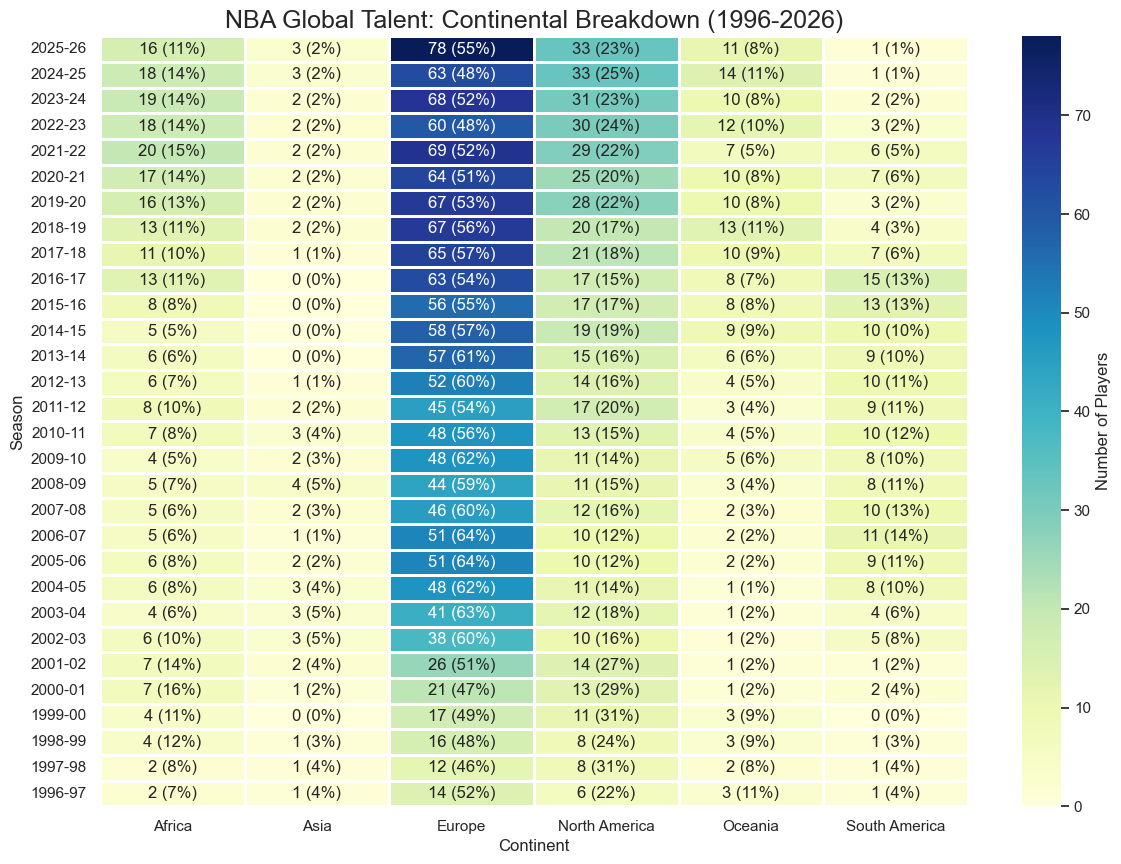

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data (excluding Grand Totals)
plot_data = continent_matrix_sorted.drop('Grand Total').drop('Grand Total', axis=1)

# 2. Calculate cleaner labels: "Count (Share%)"
row_totals = plot_data.sum(axis=1)
pct_data = plot_data.div(row_totals, axis=0) * 100
labels = plot_data.astype(str) + " (" + pct_data.round(0).astype(int).astype(str) + "%)"

# 3. Create Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(plot_data, 
            annot=labels, 
            fmt="", 
            cmap="YlGnBu", 
            linewidths=1, 
            cbar_kws={'label': 'Number of Players'})

plt.title('NBA Global Talent: Continental Breakdown (1996-2026)', fontsize=18)
plt.show()

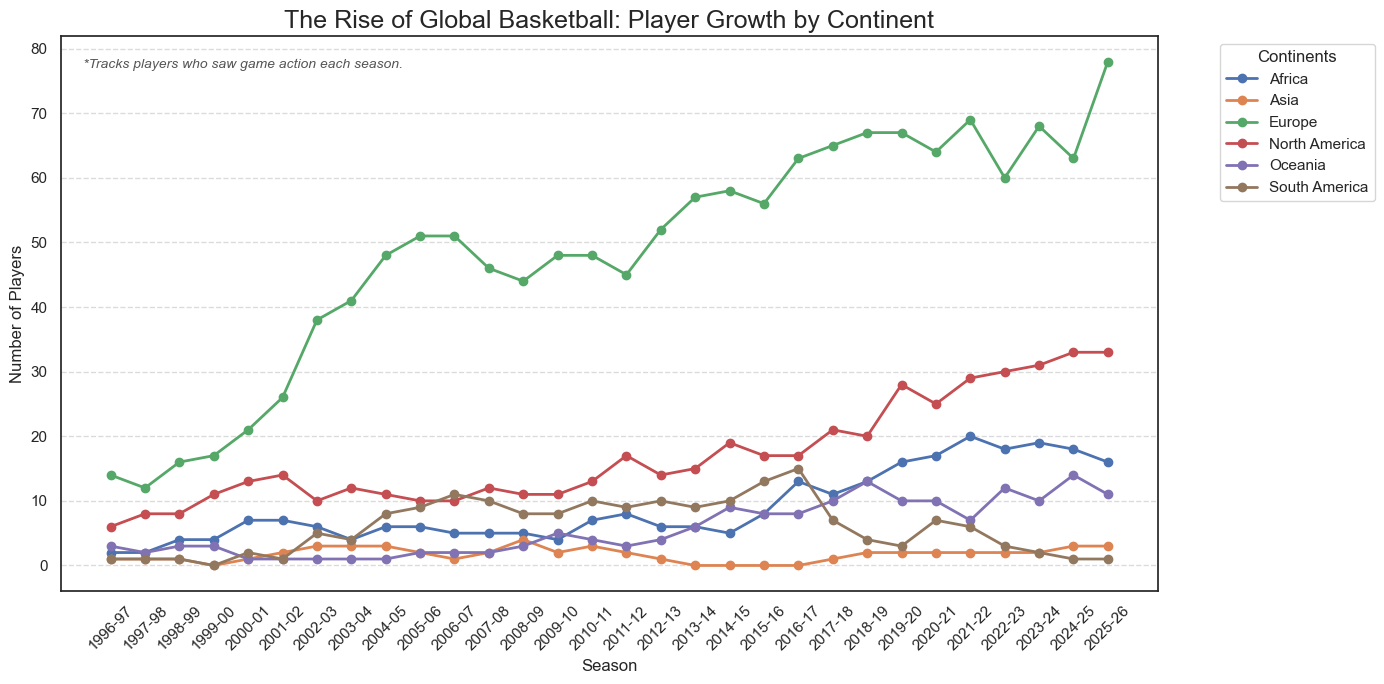

In [61]:
import matplotlib.pyplot as plt

# 1. Prepare data (Newest year is usually on top in our matrix, 
# but for a line chart we need to sort it OLD to NEW)
line_data = plot_data.sort_index()

# 2. Plotting
plt.figure(figsize=(14, 7))

# We loop through each continent to draw its line
for continent in line_data.columns:
    plt.plot(line_data.index, line_data[continent], marker='o', label=continent, linewidth=2)

# 3. Customizing the Chart
plt.title('The Rise of Global Basketball: Player Growth by Continent', fontsize=18)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.xticks(rotation=45) # Tilt years for readability
plt.legend(title="Continents", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Add the portfolio footnote INSIDE the chart rectangle (UPPER-LEFT corner)
# 0.02 aligns it neatly to the left margin, 0.96 tucks it right below the top border
plt.text(0.02, 0.96, '*Tracks players who saw game action each season.', 
         style='italic', horizontalalignment='left', verticalalignment='top',
         fontsize=10, color='#555555', transform=plt.gca().transAxes)

# 5. Save and Show
plt.tight_layout()

# Save the figure cleanly as a high-res file
plt.savefig('global_basketball_growth_by_continent.png', dpi=300, bbox_inches='tight')

plt.show()

In [29]:
# 1. Identify all players who appeared in any season BEFORE 2025-26
players_before_2025 = df[df['Season'] != '2025-26']['Player'].unique()

# 2. Filter for European players in the 2025-26 season
europe_2025 = df[(df['Season'] == '2025-26') & (df['Continent'] == 'Europe')]

# 3. Create the debut list by finding who is NOT in the historical list
# We use .copy() to ensure we can manipulate this new dataframe freely
european_debuts_full = europe_2025[~europe_2025['Player'].isin(players_before_2025)].copy()

# 4. Display every column available in your dataset
print(f"Found {len(european_debuts_full)} European players making their debut in 2025-26:")
european_debuts_full

Found 18 European players making their debut in 2025-26:


,Season (sort),Season,Player,Team,Age,Height,Weight,COLLEGE,COUNTRY,DRAFT YEAR,DRAFT ROUND,DRAFT NUMBER,Continent
978,2025,2025-26,Adama Bal,MEM,22,6-7,190.0,Santa Clara,France,Undrafted,Undrafted,Undrafted,Europe
982,2025,2025-26,Joan Beringer,MIN,19,6-11,230.0,NaN,France,2025,1,17,Europe
984,2025,2025-26,Maxime Raynaud,SAC,22,7-1,250.0,Stanford,France,2025,2,42,Europe
985,2025,2025-26,Mohamed Diawara,NYK,20,6-9,225.0,NaN,France,2025,2,51,Europe
988,2025,2025-26,Noa Essengue,CHI,19,6-8,194.0,NaN,France,2025,1,12,Europe
989,2025,2025-26,Noah Penda,ORL,21,6-7,215.0,NaN,France,2025,2,32,Europe
990,2025,2025-26,Nolan Traore,BKN,19,6-3,185.0,NaN,France,2025,1,19,Europe
1362,2025,2025-26,Alex Antetokounmpo,MIL,24,6-8,214.0,NaN,Greece,Undrafted,Undrafted,Undrafted,Europe
1440,2025,2025-26,Ben Saraf,BKN,19,6-6,200.0,NaN,Israel,2025,1,26,Europe
1580,2025,2025-26,Kasparas Jakučionis,MIA,19,6-5,200.0,Illinois-Urbana-Champaign,Lithuania,2025,1,20,Europe


In [30]:
# 1. Define the specific season we are investigating
target_season = '2024-25'

# 2. Get a list of all unique seasons that happened BEFORE 2024-25
# This ensures we don't accidentally exclude them just because they played in 2025-26
all_seasons = df['Season'].unique()
seasons_before = [s for s in all_seasons if s < target_season]

# 3. Create the "Veterans List" (Anyone who played in those previous seasons)
veterans = df[df['Season'].isin(seasons_before)]['Player'].unique()

# 4. Filter for European players in our target 2024-25 season
europe_2024 = df[(df['Season'] == target_season) & (df['Continent'] == 'Europe')]

# 5. The Debut Class: In 2024-25 Europe, but NOT in the Veterans list
debuts_2024 = europe_2025_target = europe_2024[~europe_2024['Player'].isin(veterans)].copy()

print(f"Total European Debuts in 2024-25: {len(debuts_2024)}")
debuts_2024

Total European Debuts in 2024-25: 15


,Season (sort),Season,Player,Team,Age,Height,Weight,COLLEGE,COUNTRY,DRAFT YEAR,DRAFT ROUND,DRAFT NUMBER,Continent
259,2024,2024-25,Ajay Mitchell,OKC,23,6-5,190.0,California-Santa Barbara,Belgium,2024,2,38,Europe
279,2024,2024-25,Karlo Matković,NOP,24,6-10,231.0,NaN,Bosnia and Herzegovina,2022,2,52,Europe
1000,2024,2024-25,Alex Sarr,WAS,20,7-0,205.0,NaN,France,2024,1,2,Europe
1001,2024,2024-25,Armel Traore,LAL,22,6-9,245.0,NaN,France,Undrafted,Undrafted,Undrafted,Europe
1008,2024,2024-25,Pacôme Dadiet,NYK,19,6-8,210.0,NaN,France,2024,1,25,Europe
1012,2024,2024-25,Tidjane Salaün,CHA,19,6-8,207.0,NaN,France,2024,1,6,Europe
1014,2024,2024-25,Zaccharie Risacher,ATL,20,6-8,200.0,NaN,France,2024,1,1,Europe
1275,2024,2024-25,Ariel Hukporti,NYK,23,6-11,246.0,NaN,Germany,2024,2,58,Europe
1282,2024,2024-25,Tristan da Silva,ORL,24,6-8,217.0,Colorado,Germany,2024,1,18,Europe
1728,2024,2024-25,Jesse Edwards,MIN,25,7-0,236.0,West Virginia,Netherlands,Undrafted,Undrafted,Undrafted,Europe


In [31]:
# 1. Group by College and count the players
college_counts = unique_players['COLLEGE'].value_counts(dropna=False)

# 2. Calculate the percentage share of the 540 total players
college_perc = (college_counts / len(unique_players)) * 100

# 3. Create a clean summary DataFrame
college_summary = pd.DataFrame({
    'Player Count': college_counts,
    'Percentage': college_perc.map('{:.2f}%'.format)
})

# 4. If your "None" values are showing as NaN, rename them for the report
college_summary.index = college_summary.index.fillna('None')

# Show the top results
college_summary.head(10)

,Player Count,Percentage
COLLEGE,,
None,301,55.74%
Kentucky,14,2.59%
Gonzaga,14,2.59%
Kansas,7,1.30%
Arizona,7,1.30%
Michigan,7,1.30%
Maryland,6,1.11%
Duke,6,1.11%
Oregon,6,1.11%


In [32]:
# 1. Count the occurrences of each Draft Status
draft_counts = unique_players['DRAFT ROUND'].value_counts()

# 2. Calculate the percentage based on the total unique players (540)
draft_pct = (draft_counts / len(unique_players)) * 100

# 3. Create the summary DataFrame
draft_analysis = pd.DataFrame({
    'Player Count': draft_counts,
    'Percentage': draft_pct.map('{:.2f}%'.format)
})

# 4. Display the results
draft_analysis

,Player Count,Percentage
DRAFT ROUND,,
1,212,39.26%
2,164,30.37%
Undrafted,163,30.19%
6,1,0.19%


In [33]:
# 1. Create a filtered version of unique_players without "Undrafted"
# We also want to exclude any potential 'None' or NaN values in Draft Status
drafted_only = unique_players[
    (unique_players['DRAFT YEAR'] != 'Undrafted') & 
    (unique_players['DRAFT YEAR'].notna())
].copy()

# 2. Count players per Draft Year
draft_year_counts = drafted_only['DRAFT YEAR'].value_counts()

# 3. Calculate percentages (relative to the DRAFTED total)
total_drafted = len(drafted_only)
draft_year_pct = (draft_year_counts / total_drafted) * 100

# 4. Create the Summary DataFrame
draft_year_summary = pd.DataFrame({
    'Player Count': draft_year_counts,
    'Percentage': draft_year_pct.map('{:.2f}%'.format)
})

# Show the top results
print(f"Total Drafted Players (excluding Undrafted): {total_drafted}")
draft_year_summary.head(15)

Total Drafted Players (excluding Undrafted): 377


,Player Count,Percentage
DRAFT YEAR,,
2016,23,6.10%
2025,19,5.04%
2024,17,4.51%
2014,17,4.51%
2019,16,4.24%
2013,16,4.24%
2021,15,3.98%
2005,14,3.71%
2002,13,3.45%


In [34]:
# 1. Create the base Pivot Table (same as you had)
full_status_matrix = df.pivot_table(
    index='Season', 
    columns='DRAFT ROUND', 
    values='Player', 
    aggfunc='count', 
    margins=True, 
    margins_name='Total'
).fillna(0).astype(int)

# 2. Define a function to format the cells
def format_with_pct(row):
    # The total for the season is in the 'Total' column
    row_total = row['Total']
    
    new_row = []
    for col_name, count in row.items():
        # Don't add a percentage to the "Total" column itself
        if col_name == 'Total':
            new_row.append(f"{count}")
        else:
            # Calculate percentage
            pct = (count / row_total * 100) if row_total > 0 else 0
            # Combine into "Count(Percentage%)" format
            new_row.append(f"{count} ({pct:.0f}%)")
            
    return pd.Series(new_row, index=row.index)

# 3. Apply the formatting to the matrix
formatted_matrix = full_status_matrix.apply(format_with_pct, axis=1)

# Display result
formatted_matrix

DRAFT ROUND,1,2,6,Undrafted,Total
Season,,,,,
1996-97,15 (56%),6 (22%),1 (4%),5 (19%),27
1997-98,20 (77%),4 (15%),0 (0%),2 (8%),26
1998-99,25 (76%),6 (18%),0 (0%),2 (6%),33
1999-00,25 (71%),7 (20%),0 (0%),3 (9%),35
2000-01,27 (60%),11 (24%),0 (0%),7 (16%),45
2001-02,30 (59%),12 (24%),0 (0%),9 (18%),51
2002-03,33 (52%),17 (27%),0 (0%),13 (21%),63
2003-04,39 (60%),17 (26%),0 (0%),9 (14%),65
2004-05,46 (60%),22 (29%),0 (0%),9 (12%),77


In [35]:
# 1. Filter the main dataframe for ONLY Undrafted players
undrafted_df = df[df['DRAFT ROUND'] == 'Undrafted']

# 2. Group by Season and count the players
undrafted_by_season = undrafted_df.groupby('Season')['Player'].count()

# 3. Convert to a clean DataFrame for display
undrafted_summary = undrafted_by_season.to_frame(name='Undrafted Player Count')

# 4. Display the full list
undrafted_summary

,Undrafted Player Count
Season,
1996-97,5
1997-98,2
1998-99,2
1999-00,3
2000-01,7
2001-02,9
2002-03,13
2003-04,9
2004-05,9


In [36]:
# 1. Ensure 'None' is handled (replace NaNs if necessary)
df['COLLEGE'] = df['COLLEGE'].fillna('None')

# 2. Filter for only 'None' players
none_df = df[df['COLLEGE'] == 'None']

# 3. Get counts of 'None' players per season
none_counts = none_df.groupby('Season')['Player'].count()

# 4. Get total international players per season for the percentage calculation
total_counts = df.groupby('Season')['Player'].count()

# 5. Combine into a Summary DataFrame
none_summary = pd.DataFrame({
    'College-None Count': none_counts,
    'Total International': total_counts
})

# 6. Calculate the Percentage Share
none_summary['Share %'] = (none_summary['College-None Count'] / none_summary['Total International'] * 100)

# 7. Format for the report
none_report = none_summary[['College-None Count', 'Share %']].copy()
none_report['Share %'] = none_report['Share %'].map('{:.2f}%'.format)

none_report

,College-None Count,Share %
Season,,
1996-97,13,48.15%
1997-98,9,34.62%
1998-99,13,39.39%
1999-00,14,40.00%
2000-01,19,42.22%
2001-02,26,50.98%
2002-03,40,63.49%
2003-04,44,67.69%
2004-05,54,70.13%


In [37]:
# 1. Filter out 'None' to focus purely on collegiate paths
college_only_df = df[df['COLLEGE'] != 'None'].copy()

# 2. Create the Pivot Table: Seasons as rows, Colleges as columns
# We count 'Player' to see how many internationals each school had that year
all_college_matrix = college_only_df.pivot_table(
    index='Season', 
    columns='COLLEGE', 
    values='Player', 
    aggfunc='count'
).fillna(0).astype(int)

# 3. Add a 'Season Total' to see the total collegiate international footprint
all_college_matrix['Grand Total'] = all_college_matrix.sum(axis=1)

# 4. Display the matrix
# Use .head() or .tail() to view specific eras
all_college_matrix

COLLEGE,Alabama,Arizona,Arizona State,Auburn,Baylor,Boston College,Bradley,Brigham Young,Cal State Northridge,Cal State-Fullerton,Cal-Davis,California,California State-Fullerton,California-Santa Barbara,Cleveland State,Colgate,Colorado,Colorado State,Connecticut,Dayton,Delaware,Duke,Fairfield,Florida,Florida International,Florida State,George Washington,Georgetown,Georgia Tech,Gonzaga,Grand Canyon,Hawaii,Houston,Illinois,Illinois State,Illinois-Urbana-Champaign,Indiana,Iona,Iowa State,Kansas,Kentucky,Louisiana State,Louisville,Loyola-Maryland,Marist,Marquette,Maryland,Massachusetts,Memphis,Miami,Michigan,Midland (Texas),Missouri,Nebraska,Nebraska-Lincoln,New Mexico,New Mexico State,North Carolina,Northeastern,Ohio,Ohio State,Oklahoma,Oregon,Oregon State,Pacific,Penn State,Pittsburgh,Princeton,Providence,Purdue,Rutgers,Saint Mary's,San Diego State,San Jose State,Santa Clara,Seton Hall,Siena,South Carolina,Southern California,St. Bonaventure,St. John's (NY),St. Mary's,St. Mary's (CA),St. Vincent,Stanford,Syracuse,TCU,Temple,Tennessee,Texas,Texas A&M,Texas-Austin,Tulsa,UCF,UCLA,UCONN,UNLV,Utah,Utah State,Valparaiso,Vanderbilt,Vanier,Virginia,Virginia Commonwealth,Virginia Tech,Wake Forest,Washington,Washington State,Weber State,West Virginia,Westchester C.C.,Western Kentucky,Wichita State,Winthrop,Wisconsin,Wright State,Grand Total
Season,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1996-97,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,14
1997-98,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,1,17
1998-99,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,1,20
1999-00,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,2,0,0,0,0,0,0,0,0,1,21
2000-01,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,2,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,2,0,0,0,0,0,0,0,0,1,26
2001-02,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,2,0,0,2,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,25
2002-03,0,0,0,2,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,2,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,23
2003-04,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,2,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,1,0,0,2,0,0,0,0,0,0,0,0,0,1,21
2004-05,0,0,0,1,0,0,0,1,0,0,0,2,1,0,0,1,0,1,0,0,0,1,0,0,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,1,23


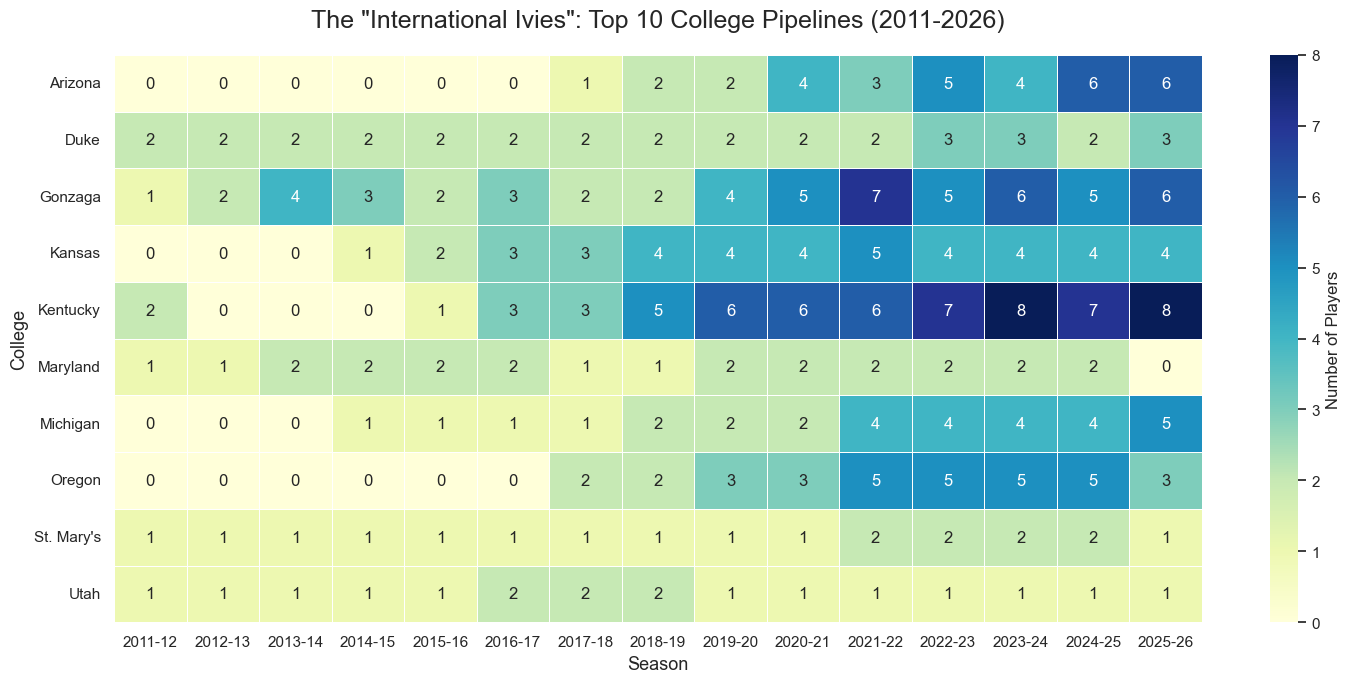

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure 'None' is handled (replace NaNs if necessary)
df['COLLEGE'] = df['COLLEGE'].fillna('None')

# 2. Filter out 'None' and restrict to seasons from 2011-12 onwards (last 15 seasons)
college_filtered = df[(df['COLLEGE'] != 'None') & (df['Season'] >= '2011-12')]

# 3. Find the Top 10 colleges by total player appearances in this 15-season window
top_10_colleges = college_filtered['COLLEGE'].value_counts().head(10).index

# 4. Pivot the data for just these 10 schools and convert to integers
heatmap_data = college_filtered[college_filtered['COLLEGE'].isin(top_10_colleges)].pivot_table(
    index='COLLEGE', 
    columns='Season', 
    values='Player', 
    aggfunc='count'
).fillna(0).astype(int)

# 5. Create the Heatmap (Adjusted size to perfectly suit a 10x15 grid)
plt.figure(figsize=(15, 7))
sns.heatmap(heatmap_data, 
            cmap="YlGnBu",      # Yellow to Green to Blue
            annot=True,         # Show the actual numbers in the boxes
            fmt="d",            # Clean integer formatting
            linewidths=.5,      # Subtle gridlines between boxes
            cbar_kws={'label': 'Number of Players'})

# 6. Labeling (Updated title to reflect the new 2011-2026 timeframe)
plt.title('The "International Ivies": Top 10 College Pipelines (2011-2026)', fontsize=18, pad=20)
plt.xlabel('Season', fontsize=13)
plt.ylabel('College', fontsize=13)

# 8. Save and Show
plt.tight_layout()

# Save the updated heatmap cleanly to your directory
plt.savefig('top_10_international_ivies_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

In [39]:
# 1. Identify all players who appeared in any season BEFORE 2025-26
# (This remains the same as your original logic)
players_before_2025 = df[df['Season'] != '2025-26']['Player'].unique()

# 2. Filter for ALL players in the 2025-26 season 
# Note: We removed the & (df['Continent'] == 'Europe') part
all_players_2025 = df[df['Season'] == '2025-26']

# 3. Create the debut list by finding who is NOT in the historical list
all_debuts_full = all_players_2025[~all_players_2025['Player'].isin(players_before_2025)].copy()

# 4. Display the results
print(f"Found {len(all_debuts_full)} total players making their debut in 2025-26:")
all_debuts_full

Found 31 total players making their debut in 2025-26:


,Season (sort),Season,Player,Team,Age,Height,Weight,COLLEGE,COUNTRY,DRAFT YEAR,DRAFT ROUND,DRAFT NUMBER,Continent
85,2025,2025-26,Lachlan Olbrich,CHI,22,6-8,236.0,None,Australia,2025,2,55,Oceania
87,2025,2025-26,Rocco Zikarsky,MIN,19,7-3,227.0,None,Australia,2025,2,45,Oceania
88,2025,2025-26,Tyrese Proctor,CLE,22,6-4,185.0,Duke,Australia,2025,2,49,Oceania
237,2025,2025-26,VJ Edgecombe,PHI,20,6-4,190.0,Baylor,Bahamas,2025,1,3,North America
447,2025,2025-26,Jahmyl Telfort,LAC,24,6-7,NaN,None,Canada,Undrafted,Undrafted,Undrafted,North America
455,2025,2025-26,Ryan Nembhard,DAL,23,5-11,180.0,Gonzaga,Canada,Undrafted,Undrafted,Undrafted,North America
720,2025,2025-26,Yang Hansen,POR,20,7-1,270.0,None,China,2025,1,16,Asia
894,2025,2025-26,Andersson Garcia,UTA,25,6-7,220.0,Texas A&M,Dominican Republic,Undrafted,Undrafted,Undrafted,North America
895,2025,2025-26,David Jones Garcia,SAS,24,6-4,210.0,Memphis,Dominican Republic,Undrafted,Undrafted,Undrafted,North America
978,2025,2025-26,Adama Bal,MEM,22,6-7,190.0,Santa Clara,France,Undrafted,Undrafted,Undrafted,Europe


In [40]:
# 1. Define the specific season we are investigating
target_season = '2024-25'

# 2. Get a list of all seasons that happened BEFORE 2024-25
all_seasons = df['Season'].unique()
seasons_before = [s for s in all_seasons if s < target_season]

# 3. Create the "Veterans List"
# Anyone who played in any season prior to our target
veterans = df[df['Season'].isin(seasons_before)]['Player'].unique()

# 4. Filter for ALL players in our target 2024-25 season
# Removed the & (df['Continent'] == 'Europe') filter
players_2024 = df[df['Season'] == target_season]

# 5. The Debut Class: In 2024-25, but NOT in the Veterans list
debuts_2024 = players_2024[~players_2024['Player'].isin(veterans)].copy()

print(f"Total Global Debuts in 2024-25: {len(debuts_2024)}")
debuts_2024

Total Global Debuts in 2024-25: 28


,Season (sort),Season,Player,Team,Age,Height,Weight,COLLEGE,COUNTRY,DRAFT YEAR,DRAFT ROUND,DRAFT NUMBER,Continent
89,2024,2024-25,Alex Ducas,OKC,24,6-7,220.0,St. Mary's (CA),Australia,Undrafted,Undrafted,Undrafted,Oceania
93,2024,2024-25,Jack McVeigh,HOU,29,6-8,215.0,Nebraska-Lincoln,Australia,Undrafted,Undrafted,Undrafted,Oceania
96,2024,2024-25,Johnny Furphy,IND,20,6-9,200.0,Kansas,Australia,2024,2,35,Oceania
100,2024,2024-25,Luke Travers,CLE,23,6-7,207.0,None,Australia,2022,2,56,Oceania
259,2024,2024-25,Ajay Mitchell,OKC,23,6-5,190.0,California-Santa Barbara,Belgium,2024,2,38,Europe
279,2024,2024-25,Karlo Matković,NOP,24,6-10,231.0,None,Bosnia and Herzegovina,2022,2,52,Europe
406,2024,2024-25,Ulrich Chomche,TOR,19,6-11,235.0,None,Cameroon,2024,2,57,Africa
407,2024,2024-25,Yves Missi,NOP,21,6-11,235.0,Baylor,Cameroon,2024,1,21,Africa
469,2024,2024-25,Emanuel Miller,CHI,25,6-7,215.0,TCU,Canada,Undrafted,Undrafted,Undrafted,North America
470,2024,2024-25,Jackson Rowe,GSW,28,6-7,210.0,Cal State-Fullerton,Canada,Undrafted,Undrafted,Undrafted,North America


In [41]:
import pandas as pd

In [42]:
df = pd.read_csv('intl_nba.csv')
df

,Season (sort),Season,Player,Team,Age,Height,Weight,COLLEGE,COUNTRY,DRAFT YEAR,DRAFT ROUND,DRAFT NUMBER
0,2024,2024-25,Bruno Fernando,TOR,26,6-9,240.0,Maryland,Angola,2019,2,34
1,2023,2023-24,Bruno Fernando,ATL,25,6-9,240.0,Maryland,Angola,2019,2,34
2,2022,2022-23,Bruno Fernando,ATL,24,6-10,240.0,Maryland,Angola,2019,2,34
3,2021,2021-22,Bruno Fernando,HOU,23,6-9,240.0,Maryland,Angola,2019,2,34
4,2020,2020-21,Bruno Fernando,ATL,22,6-9,240.0,Maryland,Angola,2019,2,34
...,...,...,...,...,...,...,...,...,...,...,...,...
2624,2002,2002-03,Oscar Torres,GSW,26,NaN,NaN,NaN,Venezuela,Undrafted,Undrafted,Undrafted
2625,2001,2001-02,Oscar Torres,HOU,25,6-6,210.0,NaN,Venezuela,Undrafted,Undrafted,Undrafted
2626,1998,1998-99,Carl Herrera,DEN,32,6-9,225.0,Houston,Venezuela,1990,2,30
2627,1997,1997-98,Carl Herrera,SAS,31,6-9,225.0,Houston,Venezuela,1990,2,30


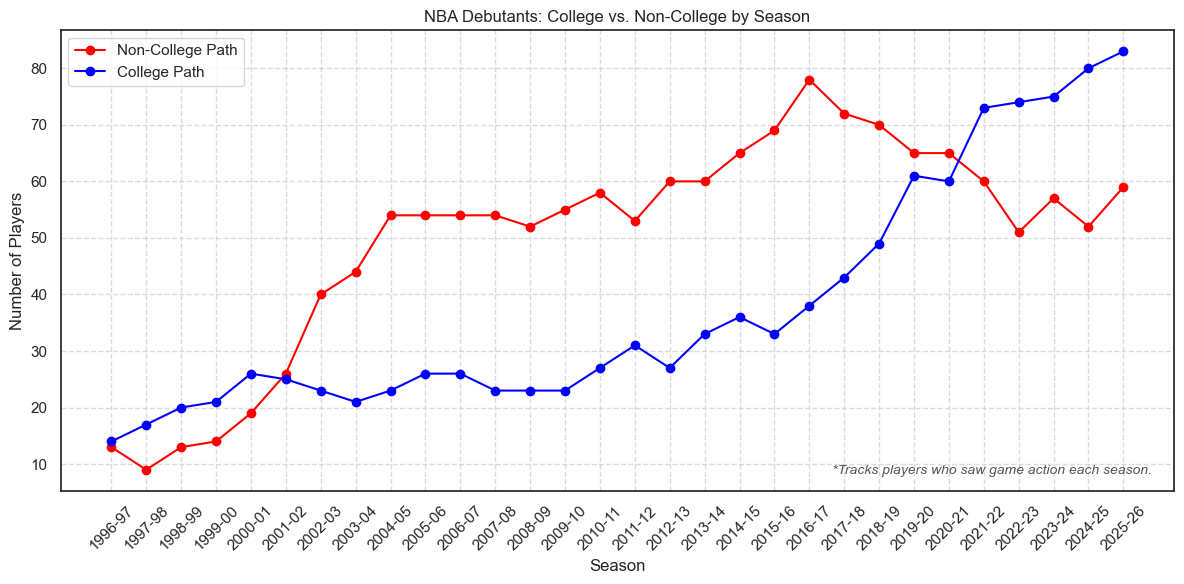

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Bring back the missing data prep from your previous cell
df['COLLEGE'] = df['COLLEGE'].fillna('None')

# 2. Get counts using your exact original filters
none_counts = df[df['COLLEGE'] == 'None'].groupby('Season')['Player'].count()
college_counts = df[df['COLLEGE'] != 'None'].groupby('Season')['Player'].count()

# 3. Plotting (Your exact old code)
plt.figure(figsize=(12, 6))

# Plot 'None' players
plt.plot(none_counts.index, none_counts.values, label='Non-College Path', marker='o', color='red')

# Plot 'College' players
plt.plot(college_counts.index, college_counts.values, label='College Path', marker='o', color='blue')

# 4. Formatting
plt.title('NBA Debutants: College vs. Non-College by Season')
plt.xlabel('Season')
plt.ylabel('Number of Players')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 5. Add your new portfolio footnote INSIDE the bottom-right of the rectangle
plt.text(0.98, 0.03, '*Tracks players who saw game action each season.', 
         style='italic', horizontalalignment='right', verticalalignment='bottom',
         fontsize=10, color='#555555', transform=plt.gca().transAxes)

# 6. Save and Show
plt.tight_layout()
plt.savefig('international_nba_college_vs_non_college.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
import pandas as pd

In [45]:
df = pd.read_csv('intl_nba.csv')

In [46]:
# 1. Find the earliest season for every player in the entire dataset
player_first_seasons = df.groupby('Player')['Season'].min().reset_index()

# 2. Count how many players debuted in each season
debut_counts = player_first_seasons['Season'].value_counts().sort_index().reset_index()
debut_counts.columns = ['Season', 'Debut_Count']

# 3. Omit the first season (1996-97) as per your requirement
# Since we don't know who played in 95-96, everyone in 96-97 looks like a debutant
debut_counts = debut_counts[debut_counts['Season'] != '1996-97']

print(debut_counts)

     Season  Debut_Count
1   1997-98            6
2   1998-99            9
3   1999-00            7
4   2000-01           17
5   2001-02           14
6   2002-03           17
7   2003-04           14
8   2004-05           17
9   2005-06           15
10  2006-07           16
11  2007-08           13
12  2008-09           11
13  2009-10            7
14  2010-11           13
15  2011-12           11
16  2012-13           19
17  2013-14           20
18  2014-15           19
19  2015-16           20
20  2016-17           28
21  2017-18           22
22  2018-19           21
23  2019-20           30
24  2020-21           18
25  2021-22           30
26  2022-23           15
27  2023-24           25
28  2024-25           28
29  2025-26           31


In [47]:
# 1. Calculate the debut season for every player in the database
player_debuts = df.groupby('Player')['Season'].min().reset_index()

# 2. Filter specifically for the 2021-22 season
debuts_21_22 = player_debuts[player_debuts['Season'] == '2021-22']

# 3. Convert the 'Player' column to a list to see the names
names_list = debuts_21_22['Player'].tolist()

# Display the count and the names
print(f"Found {len(names_list)} debutants in 2021-22:")
print(names_list)

Found 30 debutants in 2021-22:
['Alperen Sengun', 'Arnoldas Kulboka', 'Charles Bassey', 'Chris Duarte', 'Dalano Banton', 'Duane Washington Jr.', 'Eugene Omoruyi', 'Franz Wagner', 'Gabriel Lundberg', 'Georgios Kalaitzakis', 'Jaime Echenique', 'Jock Landale', 'Joel Ayayi', 'Jonathan Kuminga', 'Josh Giddey', 'Joshua Primo', 'Kai Jones', 'Kevin Pangos', 'Leandro Bolmaro', 'Lindell Wigginton', 'Marko Simonovic', 'Neemias Queta', 'Olivier Sarr', 'Omer Yurtseven', 'Petr Cornelie', 'Sandro Mamukelashvili', 'Santi Aldama', 'Usman Garuba', 'Vít Krejčí', 'Yves Pons']


In [48]:
import pandas as pd

In [49]:
df = pd.read_csv('intl_nba.csv')
df

,Season (sort),Season,Player,Team,Age,Height,Weight,COLLEGE,COUNTRY,DRAFT YEAR,DRAFT ROUND,DRAFT NUMBER
0,2024,2024-25,Bruno Fernando,TOR,26,6-9,240.0,Maryland,Angola,2019,2,34
1,2023,2023-24,Bruno Fernando,ATL,25,6-9,240.0,Maryland,Angola,2019,2,34
2,2022,2022-23,Bruno Fernando,ATL,24,6-10,240.0,Maryland,Angola,2019,2,34
3,2021,2021-22,Bruno Fernando,HOU,23,6-9,240.0,Maryland,Angola,2019,2,34
4,2020,2020-21,Bruno Fernando,ATL,22,6-9,240.0,Maryland,Angola,2019,2,34
...,...,...,...,...,...,...,...,...,...,...,...,...
2624,2002,2002-03,Oscar Torres,GSW,26,NaN,NaN,NaN,Venezuela,Undrafted,Undrafted,Undrafted
2625,2001,2001-02,Oscar Torres,HOU,25,6-6,210.0,NaN,Venezuela,Undrafted,Undrafted,Undrafted
2626,1998,1998-99,Carl Herrera,DEN,32,6-9,225.0,Houston,Venezuela,1990,2,30
2627,1997,1997-98,Carl Herrera,SAS,31,6-9,225.0,Houston,Venezuela,1990,2,30


In [50]:
# 1. Group by Team and sum up all players across all 30 seasons
# (Using .size() assumes each row in your original df is a player-season entry)
all_time_clubs = df.groupby('Team').size().reset_index(name='Total Players')

# 2. Sort by the highest count and grab just the top 10
top_10_clubs = all_time_clubs.sort_values(by='Total Players', ascending=False).head(10)

# 3. Print the clean Top 10 Leaderboard
print("RANK\tTEAM\t\t\tTOTAL PLAYERS")
print("-" * 45)
for rank, (_, row) in enumerate(top_10_clubs.iterrows(), 1):
    # The \t formatting keeps the columns aligned nicely
    print(f"#{rank}\t{row['Team']:<20}\t{row['Total Players']}")

RANK	TEAM			TOTAL PLAYERS
---------------------------------------------
#1	SAS                 	148
#2	DAL                 	141
#3	TOR                 	130
#4	UTA                 	109
#5	CLE                 	106
#6	MIL                 	100
#7	PHX                 	95
#8	DEN                 	93
#9	GSW                 	92
#10	ATL                 	92


In [51]:
import os
import pandas as pd

# 1. Create the folder for your web files
os.makedirs('country_lists', exist_ok=True)

# 2. Basic styling to make the tables look incredibly clean and professional
html_style = """
<style>
    body { font-family: Arial, sans-serif; margin: 40px; color: #333; line-height: 1.6; }
    h1 { color: #1f77b4; border-bottom: 2px solid #1f77b4; padding-bottom: 10px; }
    h2 { color: #444; margin-top: 30px; background: #f4f4f4; padding: 8px; border-left: 5px solid #1f77b4; }
    table { border-collapse: collapse; width: 100%; margin-bottom: 20px; font-size: 14px; }
    th, td { text-align: left; padding: 10px; border-bottom: 1px solid #ddd; }
    th { background-color: #1f77b4; color: white; }
    tr:hover { background-color: #f5f5f5; }
    .unique-box { display: grid; grid-template-columns: repeat(auto-fill, minmax(200px, 1fr)); gap: 10px; margin-bottom: 30px; }
    .player-card { background: #e3f2fd; padding: 10px; border-radius: 4px; font-weight: bold; text-align: center; border: 1px solid #bbdefb; }
</style>
"""

# 3. Loop through every country to build the dual-view pages
for country, group in df.groupby('COUNTRY'):
    
    # --- LIST 1: Every player from every season ---
    historical_data = group[['Season', 'Player', 'Team']].sort_values(by='Season', ascending=False)
    historical_table_html = historical_data.to_html(index=False, classes='table')
    
    # --- LIST 2: List of completely unique players ---
    # We grab unique names and sort them alphabetically
    unique_players = sorted(group['Player'].unique())
    
    # Format the unique players into a clean grid layout
    unique_html_cards = "".join([f"<div class='player-card'>{player}</div>" for player in unique_players])
    
    # 4. Assemble the final HTML page string
    page_content = f"""<!DOCTYPE html>
    <html>
    <head>
        <title>{country} - NBA International Players</title>
        {html_style}
    </head>
    <body>
        <h1>{country} NBA Alumni Dashboard</h1>
        
        <h2>1) All-Time Unique Players ({len(unique_players)} Total)</h2>
        <div class='unique-box'>
            {unique_html_cards}
        </div>
        
        <h2>2) Historical Season-by-Season Log ({len(group)} Total Appearances)</h2>
        {historical_table_html}
    </body>
    </html>
    """
    
    # 5. Save the file with a clean URL-safe name
    safe_name = country.lower().replace(" ", "_").replace("&", "and")
    with open(f'country_lists/{safe_name}.html', 'w', encoding='utf-8') as f:
        f.write(page_content)

print("Success! Created 79 dual-list dashboards automatically.")

Success! Created 79 dual-list dashboards automatically.


In [52]:
import pandas as pd

# 1. We write your live URL directly as standard text so Python doesn't break
base_url = 'https://galkevich32.github.io/global-game/country_lists/'

# 2. Generate the link for every single row automatically
df['Link'] = base_url + df['COUNTRY'].str.lower().str.replace(" ", "_").str.replace("&", "and") + '.html'

# 3. Save your brand new, completed CSV file for Flourish
df.to_csv('with_links_for_Flourish.csv', index=False)

print("🎉 Success!")
print("Look in your local project folder for a file named: 'with_links_for_Flourish.csv'")

🎉 Success!
Look in your local project folder for a file named: 'with_links_for_Flourish.csv'


In [53]:
import pandas as pd

# 1. Load your second file (the one that has both players and the L column)
# 🚨 Replace 'your_second_file.csv' with your actual filename!
df = pd.read_csv('with_links_for_Flourish.csv')

# 2. Group by country, calculate unique players, and grab the unique link from column L
flourish_final = df.groupby('COUNTRY').agg(
    Player_Count=('Player', 'nunique'),  # Counts strictly unique players per country
    L=('Link', 'first')                        # Grabs the unique link for that country from column L
).reset_index()

# 3. Sort them from highest player count to lowest (optional, but looks professional)
flourish_final = flourish_final.sort_values(by='Player_Count', ascending=False)

# 4. Save this as your brand-new, perfect 79-row CSV for Flourish
flourish_final.to_csv('flourish_final_data.csv', index=False)

print("Success! Your 79-row file 'flourish_final_data.csv' is ready for Flourish.")

Success! Your 79-row file 'flourish_final_data.csv' is ready for Flourish.
